# 🚜 Predicting the Sale Price of Bulldozers using Machine Learning

In this notebook, we're going to go through an example machine learning project with the goal of predicting the sale price of bulldozers.

Since we're trying to predict a number, this kind of problem is known as a **regression problem**.

The data and evaluation metric we'll be using (root mean square log error or RMSLE) is from the [Kaggle Bluebook for Bulldozers competition](https://www.kaggle.com/c/bluebook-for-bulldozers/overview).


## 1. Problem Definition

For this dataset, the problem we're trying to solve, or better, the question we're trying to answer is,

> How well can we predict the future sale price of a bulldozer, given its characteristics previous examples of how much similar bulldozers have been sold for?

## 2. Data

Looking at the [dataset from Kaggle](https://www.kaggle.com/c/bluebook-for-bulldozers/data), you can you it's a time series problem. This means there's a time attribute to dataset.

In this case, it's historical sales data of bulldozers. Including things like, model type, size, sale date and more.

**Bulldozer.csv** - Historical bulldozer sales examples up to 2012 (close to 400,000 examples with 50+ different attributes, including `SalePrice` which is the **target variable**).

## 3. Evaluation

For this problem, [we have set the evaluation metric to being root mean squared log error (RMSLE)](https://www.kaggle.com/c/bluebook-for-bulldozers/overview/evaluation). As with many regression evaluations, the goal will be to get this value as low as possible.


## 4. Features

Features are different parts of the data. During this step, you'll want to start finding out what you can about the data.

One of the most common ways to do this, is to create a **data dictionary**.

### Importing the data and preparing it for modelling

In [4]:
import pandas as pd
import numpy as np

In [5]:
import pandas as pd
data = pd.read_csv("Bulldozer.csv", index_col = 0, parse_dates=["saledate"] )
data.head()

/tmp/ipykernel_77633/2764414088.py:2: DtypeWarning: Columns (13,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("Bulldozer.csv", index_col = 0, parse_dates=["saledate"] )


,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
SalesID,,,,,,,,,,,,,,,,,,,,,
1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,950FII,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,PC120-6E,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,S175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 1139246 to 6333349
Data columns (total 52 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalePrice                 412698 non-null  float64       
 1   MachineID                 412698 non-null  int64         
 2   ModelID                   412698 non-null  int64         
 3   datasource                412698 non-null  int64         
 4   auctioneerID              392562 non-null  float64       
 5   YearMade                  412698 non-null  int64         
 6   MachineHoursCurrentMeter  147504 non-null  float64       
 7   UsageBand                 73670 non-null   object        
 8   saledate                  412698 non-null  datetime64[ns]
 9   fiModelDesc               412698 non-null  object        
 10  fiBaseModel               412698 non-null  object        
 11  fiSecondaryDesc           271971 non-null  object        
 12  

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to perform **Feature Engineering** by extracting specific temporal components from a datetime column named `saledate`. By breaking down a single timestamp into separate attributes like year, month, day, day of the year, and day of the week, the code transforms raw date data into meaningful numerical features that allow machine learning models or analytical tools to better identify seasonal trends, periodic patterns, and specific time-based behaviors within the dataset.

In [7]:
data["sale_year"] = data.saledate.dt.year
data["sale_month"] = data.saledate.dt.month
data["sale_day"] = data.saledate.dt.day
data["sale_dayofyear"] = data.saledate.dt.day_of_year
data["sale_dayofweek"] = data.saledate.dt.day_of_week

**----------------------------------------------------------------------------------------------------------------**

In [8]:
data.head()

,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,sale_year,sale_month,sale_day,sale_dayofyear,sale_dayofweek
SalesID,,,,,,,,,,,,,,,,,,,,,
1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,521D,...,NaN,NaN,NaN,Standard,Conventional,2006,11,16,320,3
1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,950FII,...,NaN,NaN,NaN,Standard,Conventional,2004,3,26,86,4
1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,226,...,NaN,NaN,NaN,NaN,NaN,2004,2,26,57,3
1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,PC120-6E,...,NaN,NaN,NaN,NaN,NaN,2011,5,19,139,3
1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,S175,...,NaN,NaN,NaN,NaN,NaN,2009,7,23,204,3


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 1139246 to 6333349
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalePrice                 412698 non-null  float64       
 1   MachineID                 412698 non-null  int64         
 2   ModelID                   412698 non-null  int64         
 3   datasource                412698 non-null  int64         
 4   auctioneerID              392562 non-null  float64       
 5   YearMade                  412698 non-null  int64         
 6   MachineHoursCurrentMeter  147504 non-null  float64       
 7   UsageBand                 73670 non-null   object        
 8   saledate                  412698 non-null  datetime64[ns]
 9   fiModelDesc               412698 non-null  object        
 10  fiBaseModel               412698 non-null  object        
 11  fiSecondaryDesc           271971 non-null  object        
 12  

In [10]:
data.sort_values(by="saledate", inplace=True)
data.head()

,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,sale_year,sale_month,sale_day,sale_dayofyear,sale_dayofweek
SalesID,,,,,,,,,,,,,,,,,,,,,
1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,TD20,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,17,1
1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,1989-01-31,A66,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,31,1
1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,1989-01-31,D7G,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,31,31,1
1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,1989-01-31,A62,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,31,1
1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,1989-01-31,D3B,...,None or Unspecified,PAT,Lever,NaN,NaN,1989,1,31,31,1


In [11]:
del data["saledate"]
data.head()

,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,sale_year,sale_month,sale_day,sale_dayofyear,sale_dayofweek
SalesID,,,,,,,,,,,,,,,,,,,,,
1646770,9500.0,1126363,8434,132,18.0,1974,NaN,NaN,TD20,TD20,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,17,1
1821514,14000.0,1194089,10150,132,99.0,1980,NaN,NaN,A66,A66,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,31,1
1505138,50000.0,1473654,4139,132,99.0,1978,NaN,NaN,D7G,D7,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,31,31,1
1671174,16000.0,1327630,8591,132,99.0,1980,NaN,NaN,A62,A62,...,NaN,NaN,NaN,Standard,Conventional,1989,1,31,31,1
1329056,22000.0,1336053,4089,132,99.0,1984,NaN,NaN,D3B,D3,...,None or Unspecified,PAT,Lever,NaN,NaN,1989,1,31,31,1


**----------------------------------------------------------------------------------------------------------------**

The purpose of this code snippet is to **verify the data type** of a specific column in a Pandas DataFrame. By using the function `pd.api.types.is_object_dtype(data.YearMade)`, the user is checking whether the `YearMade` column is stored as an **object** (which usually signifies strings or mixed data types in Pandas). Since the output is `False`, it confirms that the column is not a string/object but is instead stored as a different type, most likely a **numerical** type (like `int64` or `float64`), which is appropriate for performing mathematical operations or time-based analysis on year data.

In [12]:
pd.api.types.is_object_dtype(data.YearMade)

False

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **programmatically check** if the column `fiModelDesc` in the DataFrame is stored as an **object data type**. Since the output is `True`, it confirms that this column contains non-numeric data, such as strings or mixed types, which often indicates categorical information that might need further transformation (like converting it to a `category` type) before being used in a machine learning model.

In [13]:
pd.api.types.is_object_dtype(data.fiModelDesc)

True

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **evaluate the data format** of the `fiModelDesc` column by checking if it belongs to the **object data type** in Pandas. The `True` result indicates that the column contains string or mixed-type data rather than numeric values, which is a common diagnostic step used to identify **categorical variables** that may require encoding or conversion into a proper category format for more efficient data processing and machine learning.

In [14]:
for col_name, col_content in data.items():
    if pd.api.types.is_object_dtype(col_content):
        data[col_name] = col_content.astype("category")

**----------------------------------------------------------------------------------------------------------------**

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 1646770 to 6283635
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalePrice                 412698 non-null  float64 
 1   MachineID                 412698 non-null  int64   
 2   ModelID                   412698 non-null  int64   
 3   datasource                412698 non-null  int64   
 4   auctioneerID              392562 non-null  float64 
 5   YearMade                  412698 non-null  int64   
 6   MachineHoursCurrentMeter  147504 non-null  float64 
 7   UsageBand                 73670 non-null   category
 8   fiModelDesc               412698 non-null  category
 9   fiBaseModel               412698 non-null  category
 10  fiSecondaryDesc           271971 non-null  category
 11  fiModelSeries             58667 non-null   category
 12  fiModelDescriptor         74816 non-null   category
 13  ProductSize               1

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **inspect and list the unique labels** stored within a categorical column named `Grouser_Type`. By accessing the `.cat.categories` attribute, the code retrieves the underlying set of distinct values (in this case, 'Double' and 'Triple') that Pandas has identified for that specific category, allowing the user to understand the distribution and variety of the categorical data stored in that column.

In [16]:
data.Grouser_Type.cat.categories

Index(['Double', 'Single', 'Triple'], dtype='object')

**----------------------------------------------------------------------------------------------------------------**

In [17]:
import numpy as np
np.unique(data.Grouser_Type.cat.codes, return_counts=True)

(array([-1,  0,  1,  2], dtype=int8), array([310505,  86998,      2,  15193]))

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **retrieve and display the available category names** within the `Differential_Type` column of the DataFrame. By using the `.cat.categories` accessor, the code reveals the four specific distinct classes—'Limited Slip', 'Locking', 'No Spin', and 'Standard'—defined for this categorical variable, which helps the user understand the classification structure of the data and verify that the column has been correctly converted into a **categorical data type**.

In [18]:
data.Differential_Type.cat.categories

Index(['Limited Slip', 'Locking', 'No Spin', 'Standard'], dtype='object')

**----------------------------------------------------------------------------------------------------------------**

In [19]:
for col_name, col_content in data.items():
    if pd.api.types.is_categorical_dtype(col_content):
        data[col_name] = col_content.cat.codes

/tmp/ipykernel_77633/3167145931.py:2: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(col_content):


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 1646770 to 6283635
Data columns (total 56 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalePrice                 412698 non-null  float64
 1   MachineID                 412698 non-null  int64  
 2   ModelID                   412698 non-null  int64  
 3   datasource                412698 non-null  int64  
 4   auctioneerID              392562 non-null  float64
 5   YearMade                  412698 non-null  int64  
 6   MachineHoursCurrentMeter  147504 non-null  float64
 7   UsageBand                 412698 non-null  int8   
 8   fiModelDesc               412698 non-null  int16  
 9   fiBaseModel               412698 non-null  int16  
 10  fiSecondaryDesc           412698 non-null  int16  
 11  fiModelSeries             412698 non-null  int16  
 12  fiModelDescriptor         412698 non-null  int16  
 13  ProductSize               412698 non-null 

### SalePrice Distribution by Year

Let's visualize the distribution of `SalePrice` across different `sale_year` to observe any temporal trends or patterns in the pricing of bulldozers.

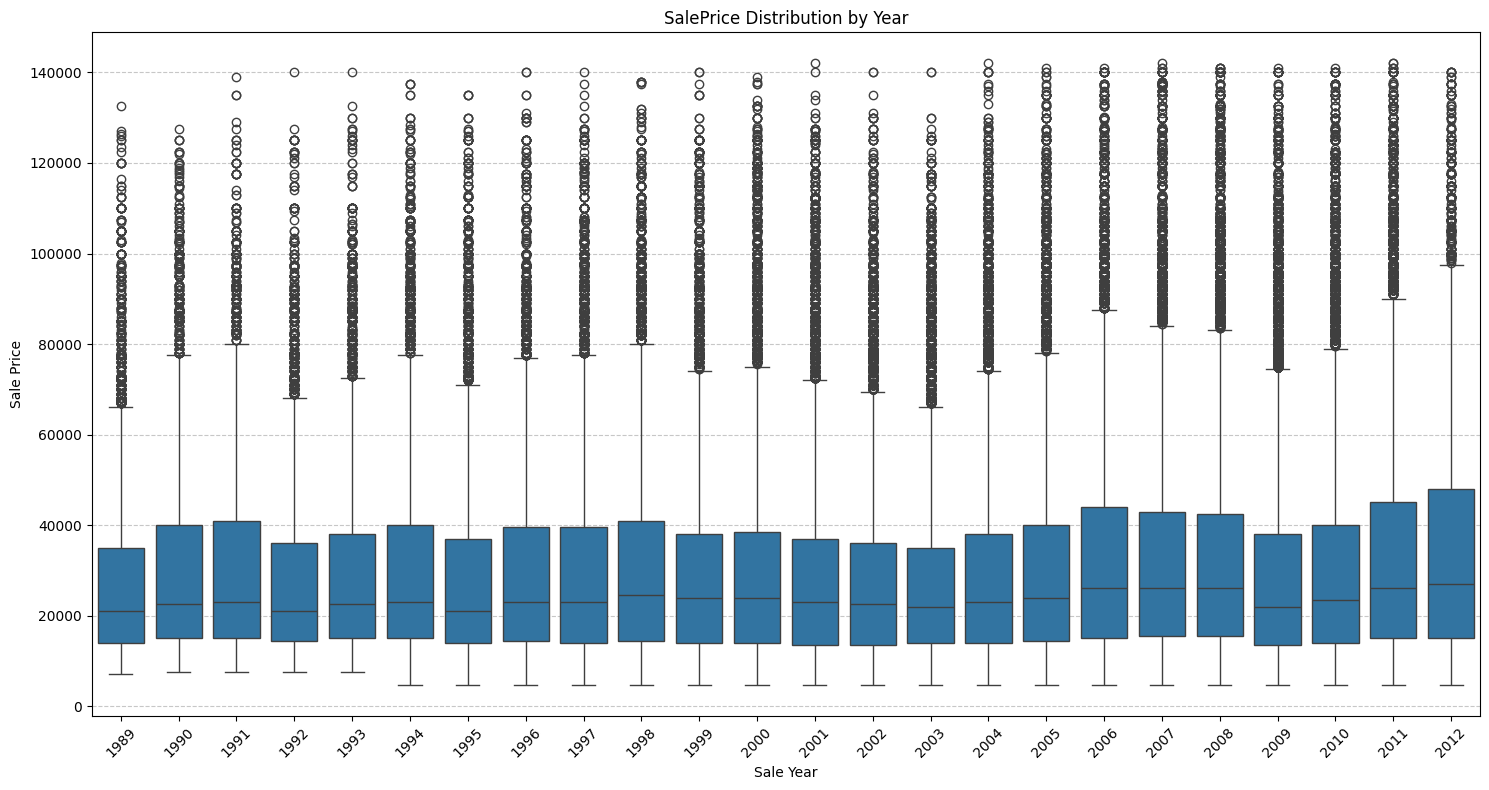

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='sale_year', y='SalePrice', data=data)
plt.title('SalePrice Distribution by Year')
plt.xlabel('Sale Year')
plt.ylabel('Sale Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation Matrix

Let's visualize the correlation matrix to understand the relationships between numerical features. This can help identify highly correlated features or features that have a strong relationship with the target variable `SalePrice`.

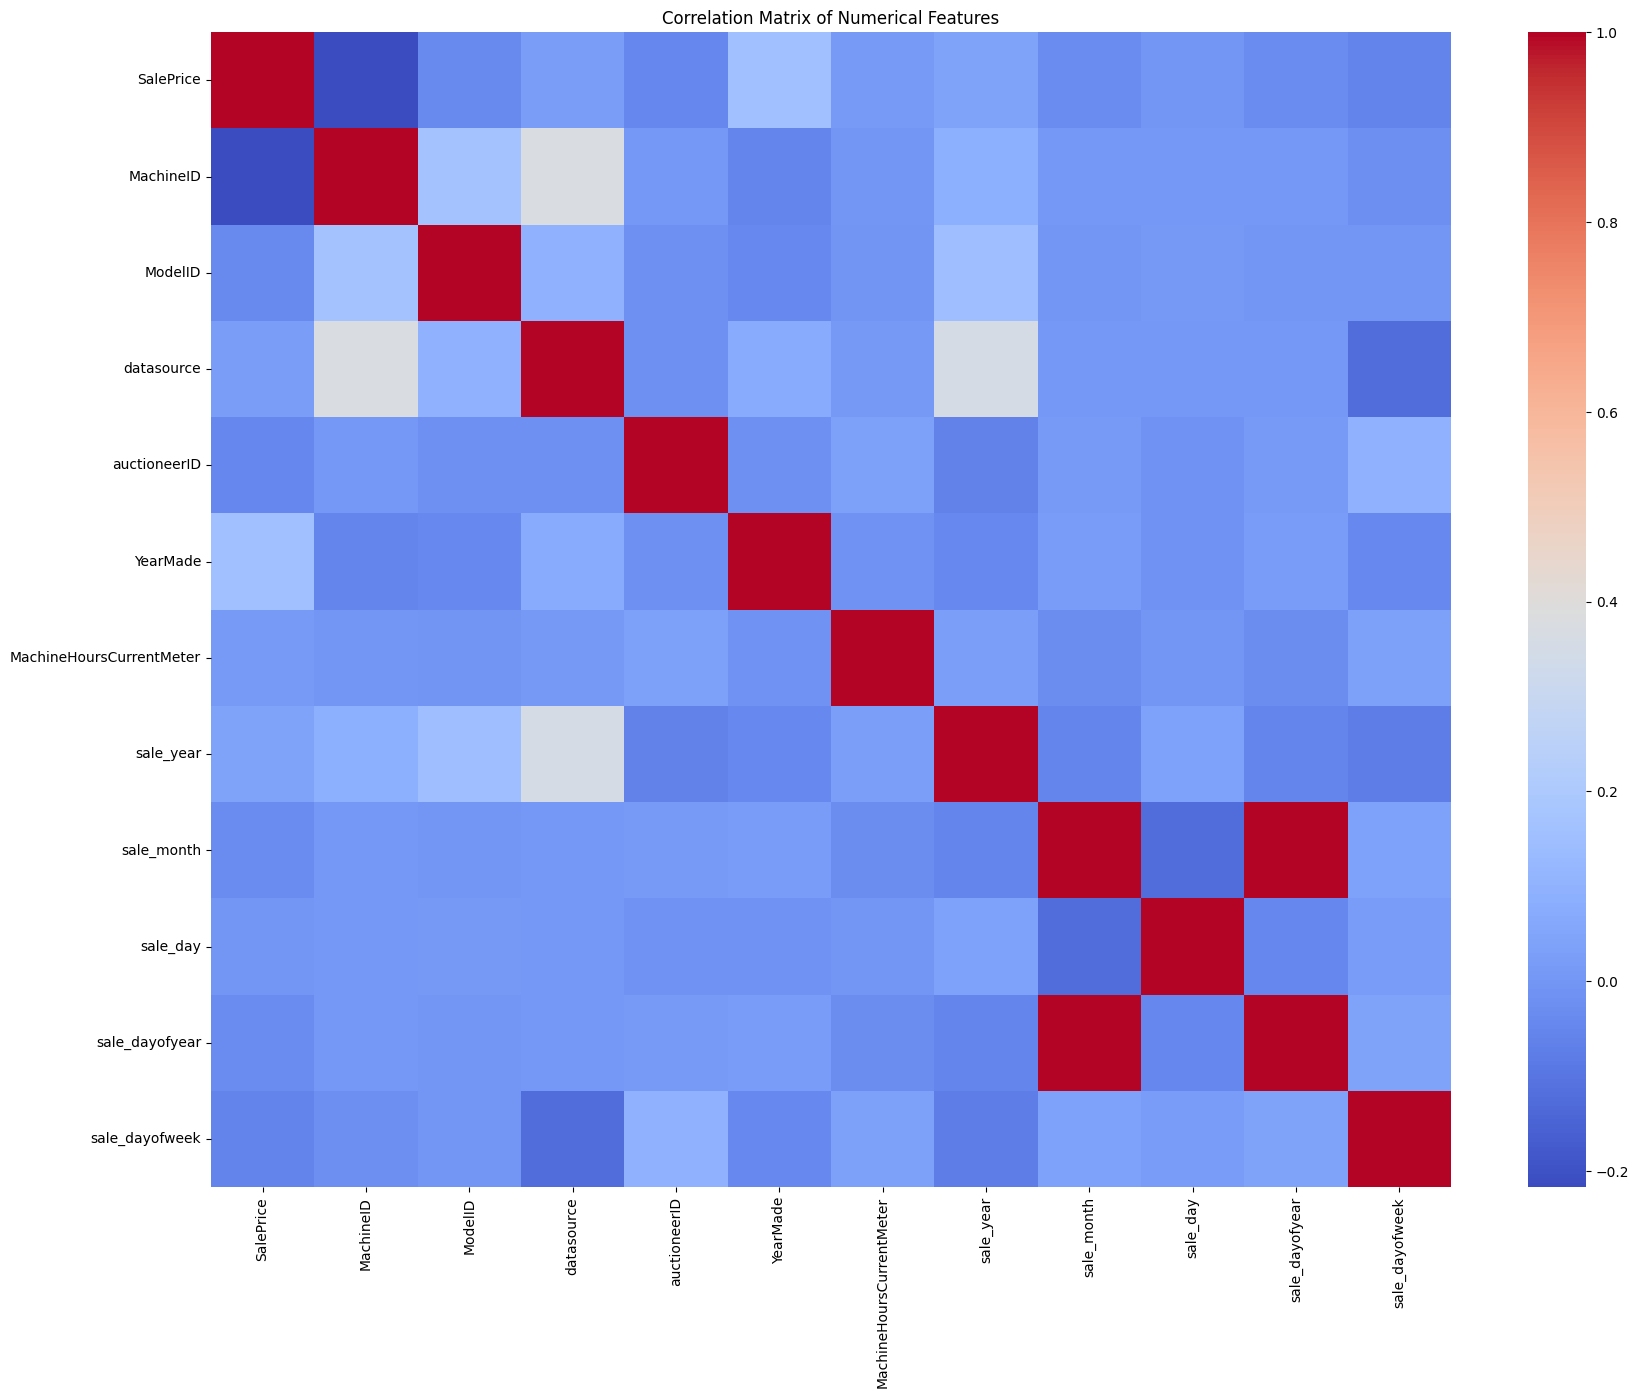

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = data.select_dtypes(include=['int64', 'int32', 'float64']).corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [23]:
import numpy as np

data["auctioneerID_imputed"] = data.auctioneerID.isna()
data.auctioneerID.fillna(data.auctioneerID.median(), inplace=True)

data["MachineHoursCurrentMeter_imputed"] = data.MachineHoursCurrentMeter.isna()
data.MachineHoursCurrentMeter.fillna(data.MachineHoursCurrentMeter.median(), inplace=True)

data.loc[data['YearMade'] < 1900, 'YearMade'] = np.nan
data["YearMade_imputed"] = data.YearMade.isna()
data.YearMade.fillna(data.YearMade.median(), inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 1646770 to 6283635
Data columns (total 59 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   SalePrice                         412698 non-null  float64
 1   MachineID                         412698 non-null  int64  
 2   ModelID                           412698 non-null  int64  
 3   datasource                        412698 non-null  int64  
 4   auctioneerID                      412698 non-null  float64
 5   YearMade                          412698 non-null  float64
 6   MachineHoursCurrentMeter          412698 non-null  float64
 7   UsageBand                         412698 non-null  int8   
 8   fiModelDesc                       412698 non-null  int16  
 9   fiBaseModel                       412698 non-null  int16  
 10  fiSecondaryDesc                   412698 non-null  int16  
 11  fiModelSeries                     412698 non-null 

/tmp/ipykernel_77633/2811901414.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.auctioneerID.fillna(data.auctioneerID.median(), inplace=True)
/tmp/ipykernel_77633/2811901414.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [24]:
X_train = data.loc[data.sale_year < 2011 , "MachineID":]
y_train = data.SalePrice[data.sale_year < 2011]

X_test = data.loc[data.sale_year == 2011 , "MachineID":]
y_test = data.SalePrice[data.sale_year == 2011]

X_train.tail()

,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,...,Differential_Type,Steering_Controls,sale_year,sale_month,sale_day,sale_dayofyear,sale_dayofweek,auctioneerID_imputed,MachineHoursCurrentMeter_imputed,YearMade_imputed
SalesID,,,,,,,,,,,,,,,,,,,,,
2655153,1933861,26225,149,16.0,1996.0,0.0,-1,1557,471,-1,...,-1,-1,2010,12,29,363,2,False,False,False
2530714,1299924,3803,149,16.0,1991.0,0.0,-1,1726,521,49,...,3,1,2010,12,29,363,2,False,False,False
1771099,1459774,2232,132,16.0,2000.0,0.0,-1,3802,1393,-1,...,-1,-1,2010,12,29,363,2,False,True,False
2698005,1791379,22666,149,16.0,1997.0,0.0,-1,2206,703,49,...,-1,-1,2010,12,29,363,2,False,False,False
1209919,1000792,4149,121,3.0,1996.0,14929.0,2,2390,717,102,...,-1,-1,2010,12,30,364,3,False,False,True


In [25]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_jobs = -1)

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **train a machine learning model** and measure its execution time. By calling `regressor.fit(X_train, y_train)`, the code is teaching a **Random Forest Regressor** to find patterns in the training data, while the `%%time` magic command provides a detailed breakdown of the **CPU and Wall time** required for the process. Notably, the `n_jobs=-1` parameter indicates that the model is configured to use **parallel processing** (all available CPU cores) to speed up the training phase, which is why the "Wall time" is significantly shorter than the "CPU user time."

In [26]:
%%time
regressor.fit(X_train, y_train)

CPU times: user 16min 37s, sys: 6.71 s, total: 16min 44s
Wall time: 9min 41s


RandomForestRegressor(n_jobs=-1)

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code snippet is to calculate a numerical value using a basic arithmetic expression within a code cell, which serves as a quick calculator to determine a specific result or ratio. By multiplying 100, 5, and 2 and then dividing by 60, the code computes the final floating-point value of approximately 16.67, often used in data analysis to estimate time durations (like converting minutes to hours) or to scale specific weights and parameters within a larger workflow.

In [27]:
100*5*2/60

16.666666666666668

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **evaluate the predictive accuracy** of a regression model by calculating a comprehensive suite of evaluation metrics for both the training and testing datasets. By defining the `CalculatePerformance` function, the user can simultaneously compare scores like **$R^2$ (coefficient of determination)**, **MAE (Mean Absolute Error)**, **MAPE**, and **RMSLE**, which helps in diagnosing the model's overall performance and identifying potential **overfitting**, as evidenced by the discrepancy between the high training scores and the lower test scores shown in the output.

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_log_error

def CalculatePerformance(regressor, X_train,X_test, y_train, y_test):
    pred_train = regressor.predict(X_train)
    pred_test = regressor.predict(X_test)

    results ={
        "Train R2 Score:": r2_score(y_train, pred_train),
        "Test R2 Score:": r2_score(y_test, pred_test),
        "Train MAE:": mean_absolute_error(y_train, pred_train),
        "Test MAE:": mean_absolute_error(y_test, pred_test),
        "Train MAPE:": mean_absolute_percentage_error(y_train, pred_train),
        "Test MAPE:": mean_absolute_percentage_error(y_test, pred_test),
        "Train RMSLE:": root_mean_squared_log_error(y_train, pred_train),
        "Test RMSLE:": root_mean_squared_log_error(y_test, pred_test),
    }

    return results

In [29]:
CalculatePerformance(regressor, X_train,X_test, y_train, y_test)

{'Train R2 Score:': 0.9873951129946377,
 'Test R2 Score:': 0.8588103761605876,
 'Train MAE:': 1568.724174810345,
 'Test MAE:': 5921.479749126345,
 'Train MAPE:': 0.05844838633120004,
 'Test MAPE:': 0.18584621267092002,
 'Train RMSLE:': 0.08476659699342722,
 'Test RMSLE:': 0.24466263954877168}

**----------------------------------------------------------------------------------------------------------------**

In [30]:
regressor = RandomForestRegressor(max_samples=27586, n_jobs = -1)

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **train a Random Forest Regressor** on a subset of the data and immediately **evaluate its predictive accuracy** using multiple regression metrics. By setting `max_samples=27586`, the user is intentionally limiting the amount of data each individual tree in the forest sees to speed up training time (measured at 34.3 seconds), while the subsequent call to `CalculatePerformance` provides a detailed comparison of training and testing scores—such as **$R^2$**, **MAE**, and **RMSLE**—to verify how well the model generalizes to unseen data and to ensure that reducing the sample size hasn't significantly compromised its performance.

In [31]:
%%time
regressor.fit(X_train, y_train)

CPU times: user 1min 47s, sys: 757 ms, total: 1min 48s
Wall time: 1min 2s


RandomForestRegressor(max_samples=27586, n_jobs=-1)

In [32]:
CalculatePerformance(regressor, X_train,X_test, y_train, y_test)

{'Train R2 Score:': 0.8969823439894437,
 'Test R2 Score:': 0.8468317033843711,
 'Train MAE:': 4674.567201362018,
 'Test MAE:': 6186.7894454072775,
 'Train MAPE:': 0.17688620761067245,
 'Test MAPE:': 0.19938221955306948,
 'Train RMSLE:': 0.22437481238253867,
 'Test RMSLE:': 0.25448524328535266}

## Parametre Optimizasyonu

The purpose of this code is to **configure and initialize a Hyperparameter Tuning process** to find the optimal settings for a Random Forest Regressor. By defining a dictionary of potential values for parameters like `n_estimators`, `max_depth`, and `min_samples_split`, and passing them into `RandomizedSearchCV`, the user is setting up an automated search that will test different random combinations of these settings across **5-fold cross-validation** (`cv=5`) to maximize the model's performance while maximizing the negative root mean squared log error, which effectively minimizes the actual root mean squared log error.

In [33]:
params ={
    "n_estimators": [100 ,200 ,300 ,400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [10,20,50,70],
    "max_features": [0.5, 0.75, 1],
    "max_samples": [22068]
}

In [34]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [35]:
from sklearn.metrics import make_scorer

def mali_score(y_test, y_pred):
    return np.mean(y_test - y_pred)

mali_scorer = make_scorer(mali_score)

search_model = RandomizedSearchCV(RandomForestRegressor(),
                                 param_distributions= params,
                                 cv = 5,
                                 n_iter = 3,
                                 scoring = "neg_root_mean_squared_log_error",
                                 verbose = 5,
                                  n_jobs = -1
                                 )

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **execute the randomized hyperparameter search** and retrieve the most effective model configuration. By calling `search_model.fit(X_train, y_train)`, the user initiates a process that tests 3 different hyperparameter combinations across 5-fold cross-validation (totaling 15 fits), and the subsequent `search_model.best_estimator_` command reveals the **final optimized model**, which in this case uses specific parameters like `max_depth=None` and `min_samples_split=10` to achieve the best predictive performance based on the search criteria.

In [36]:
%%time
search_model.fit(X_train,y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
CPU times: user 1min 27s, sys: 1.23 s, total: 1min 28s
Wall time: 18min 42s


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=3, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': [0.5, 0.75, 1],
                                        'max_samples': [22068],
                                        'min_samples_split': [10, 20, 50, 70],
                                        'n_estimators': [100, 200, 300, 400]},
                   scoring='neg_root_mean_squared_log_error', verbose=5)

In [37]:
search_model.best_estimator_

RandomForestRegressor(max_features=0.5, max_samples=22068, min_samples_split=10,
                      n_estimators=300)

**----------------------------------------------------------------------------------------------------------------**

In [38]:
cv_res = pd.DataFrame(search_model.cv_results_)
cv_res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_samples,param_max_features,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,55.474304,1.187248,2.452264,0.255916,200,50,22068,0.50,10,"{'n_estimators': 200, 'min_samples_split': 50,...",-0.411847,-0.351128,-0.309183,-0.328222,-0.422937,-0.364663,0.045191,3
1,213.979559,3.837737,7.353673,0.613211,400,20,22068,0.75,20,"{'n_estimators': 400, 'min_samples_split': 20,...",-0.365280,-0.300163,-0.253482,-0.288764,-0.370102,-0.315558,0.045289,2
2,124.500688,4.426071,6.004409,1.193708,300,10,22068,0.50,None,"{'n_estimators': 300, 'min_samples_split': 10,...",-0.365975,-0.297901,-0.252313,-0.280031,-0.376522,-0.314548,0.048636,1


**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **generate predictions** on unseen data using the previously tuned model. By calling `search_model.predict(X_test)`, the code applies the **optimized Random Forest Regressor** to the test dataset's features to estimate numerical target values, resulting in an array of continuous floating-point predictions that can then be compared against the actual values to assess the model's final real-world performance.

In [39]:
search_model.predict(X_test)

array([19360.83111027, 38934.92829485, 14632.10776034, ...,
       12006.93178211, 22153.19220178, 15875.73611941])

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **instantiate and train an optimized Random Forest Regressor** using a specific set of manually selected hyperparameters. By defining `good_model` with tuned settings—such as `min_samples_leaf=7` to reduce overfitting and `max_features=0.5` to increase tree diversity—the user is aiming to create a robust model that balances complexity and generalization, then immediately fits this "good" configuration to the training data to prepare it for final predictions.

In [40]:
from sklearn.ensemble import RandomForestRegressor

good_model = RandomForestRegressor(n_estimators  =100, min_samples_leaf = 7, min_samples_split = 4,
                                  max_features= 0.5, n_jobs = -1, max_depth = None, max_samples =None)
good_model.fit(X_train,y_train)

RandomForestRegressor(max_features=0.5, min_samples_leaf=7, min_samples_split=4,
                      n_jobs=-1)

**----------------------------------------------------------------------------------------------------------------**

The purpose of this code is to **validate the effectiveness of the final optimized model** by calculating a comprehensive set of performance metrics for both the training and testing datasets. By passing `good_model` through the `CalculatePerformance` function, the user is assessing how well the manually tuned hyperparameters have balanced the model's accuracy, checking for a high **$R^2$ score** and low error values like **MAE** and **RMSLE** to ensure the model maintains strong predictive power on unseen data while minimizing the risk of overfitting.

In [41]:
CalculatePerformance(good_model, X_train,X_test, y_train, y_test)

{'Train R2 Score:': 0.9393029860439318,
 'Test R2 Score:': 0.865872480272743,
 'Train MAE:': 3522.446873269696,
 'Test MAE:': 5747.366267519039,
 'Train MAPE:': 0.13084636149544698,
 'Test MAPE:': 0.18224965238437624,
 'Train RMSLE:': 0.1729267423512282,
 'Test RMSLE:': 0.2371728230803453}

### Feature Importance Analysis

Let's visualize the feature importances from our `good_model` to understand which features are most influential in predicting the `SalePrice`. This will help us gain insights into the model's decision-making process.

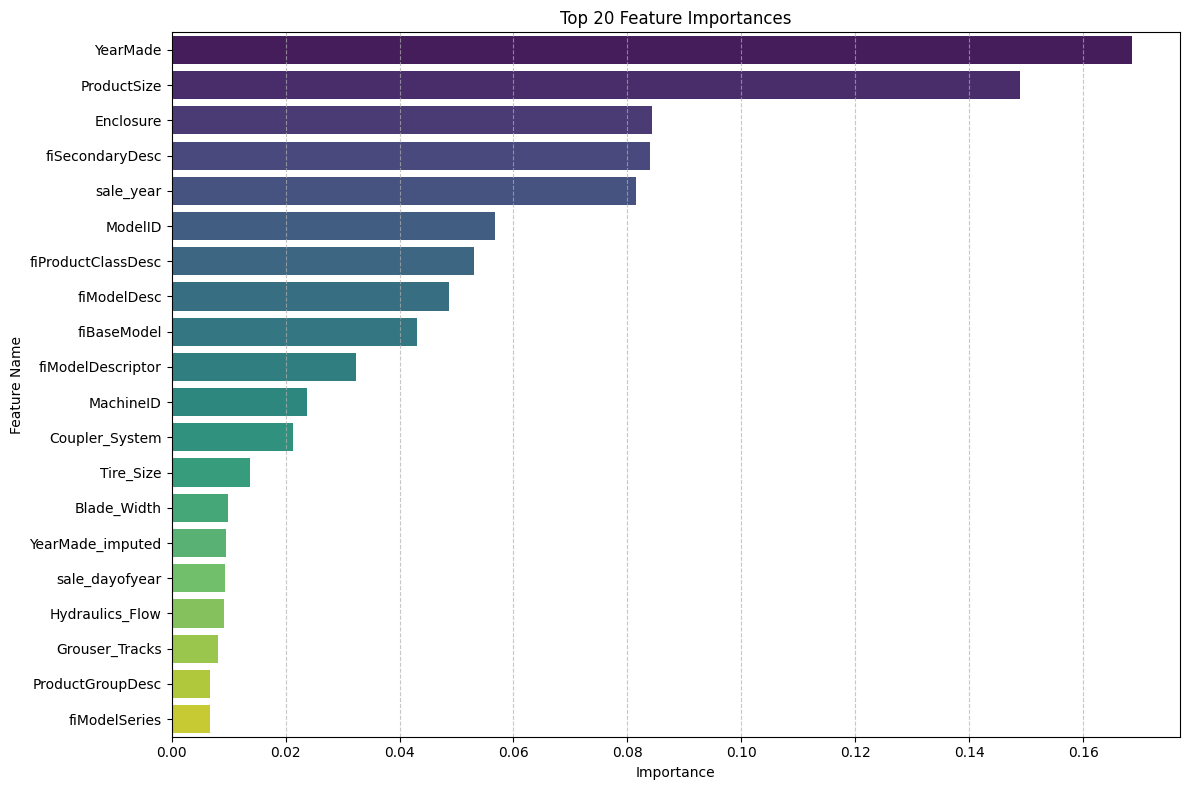

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = good_model.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation of Feature Importances

The feature importance plot reveals which features `good_model` considered most influential in predicting the `SalePrice`.

From the plot, we can observe:

*   **`YearMade`** and **`ProductSize`** are consistently at the top, indicating that the age and size of a bulldozer are very strong predictors of its sale price. This aligns with common sense, as newer and larger machines are generally more expensive.
*   Other significant features include **`Enclosure`**, **`fiSecondaryDesc`**, and **`sale_year`**, suggesting that the type of enclosure, a secondary description of the model, and the year of sale also play crucial roles.
*   Many of the highly specific categorical features (e.g., `Travel_Controls`, `Differential_Type`, `Turbocharged`) tend to have lower importances, though they still contribute to the model.
*   Features related to `imputed` status (e.g., `auctioneerID_imputed`, `MachineHoursCurrentMeter_imputed`, `YearMade_imputed`) are among the least important. This is expected, as these are binary flags indicating missingness rather than intrinsic characteristics of the bulldozer.

This analysis confirms that the model is learning from logical attributes of the bulldozers. Understanding these importances can guide further feature engineering or help in interpreting model behavior.

---

### Exploring Target Variable Transformation

Given that the evaluation metric for this project is Root Mean Squared Log Error (RMSLE), it's often beneficial to transform the target variable (`SalePrice`) using a logarithmic function. This can help normalize skewed distributions and make the model's errors more symmetrical, which often leads to better RMSLE scores.

We can apply a `np.log1p()` transformation to `SalePrice` before training the model, and then inverse transform the predictions using `np.expm1()` to get them back to the original scale. Let's try this and re-evaluate the model.

First, we need to create new `y_train` and `y_test` variables with the `SalePrice` transformed.

In [43]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("Original y_train head:")
print(y_train.head())
print("\nLog-transformed y_train head:")
print(y_train_log.head())

print("\nOriginal y_test head:")
print(y_test.head())
print("\nLog-transformed y_test head:")
print(y_test_log.head())

Original y_train head:
SalesID
1646770     9500.0
1821514    14000.0
1505138    50000.0
1671174    16000.0
1329056    22000.0
Name: SalePrice, dtype: float64

Log-transformed y_train head:
SalesID
1646770     9.159152
1821514     9.546884
1505138    10.819798
1671174     9.680406
1329056     9.998843
Name: SalePrice, dtype: float64

Original y_test head:
SalesID
1168983    17500.0
1210607    28500.0
1622760     9500.0
1206489    28000.0
1209907    39000.0
Name: SalePrice, dtype: float64

Log-transformed y_test head:
SalesID
1168983     9.770013
1210607    10.257694
1622760     9.159152
1206489    10.239996
1209907    10.571343
Name: SalePrice, dtype: float64


### Retraining and Re-evaluating Model with Log-Transformed Target

Now we will retrain our `good_model` using the `y_train_log` target variable. After training, we'll obtain predictions and inverse-transform them using `np.expm1()` to evaluate the model's performance on the original scale of `SalePrice`.

In [44]:
%%time
good_model_log_transformed = RandomForestRegressor(n_estimators  =100, min_samples_leaf = 7, min_samples_split = 4,
                                                  max_features= 0.5, n_jobs = -1, max_depth = None, max_samples =None)

good_model_log_transformed.fit(X_train, y_train_log)

print("Model trained with log-transformed target.")

Model trained with log-transformed target.
CPU times: user 6min 56s, sys: 1.11 s, total: 6min 57s
Wall time: 4min 10s


In [45]:
pred_train_log = good_model_log_transformed.predict(X_train)
pred_test_log = good_model_log_transformed.predict(X_test)

pred_train_original = np.expm1(pred_train_log)
pred_test_original = np.expm1(pred_test_log)

from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_log_error

print("Performance with log-transformed target during training:")
results_log_transformed = {
    "Train R2 Score:": r2_score(y_train, pred_train_original),
    "Test R2 Score:": r2_score(y_test, pred_test_original),
    "Train MAE:": mean_absolute_error(y_train, pred_train_original),
    "Test MAE:": mean_absolute_error(y_test, pred_test_original),
    "Train MAPE:": mean_absolute_percentage_error(y_train, pred_train_original),
    "Test MAPE:": mean_absolute_percentage_error(y_test, pred_test_original),
    "Train RMSLE:": root_mean_squared_log_error(y_train_log, pred_train_log),
    "Test RMSLE:": root_mean_squared_log_error(y_test_log, pred_test_log)
}

for metric, value in results_log_transformed.items():
    print(f"{metric} {value:.4f}")

Performance with log-transformed target during training:
Train R2 Score: 0.9347
Test R2 Score: 0.8480
Train MAE: 3513.7741
Test MAE: 5994.5258
Train MAPE: 0.1214
Test MAPE: 0.1764
Train RMSLE: 0.0151
Test RMSLE: 0.0216


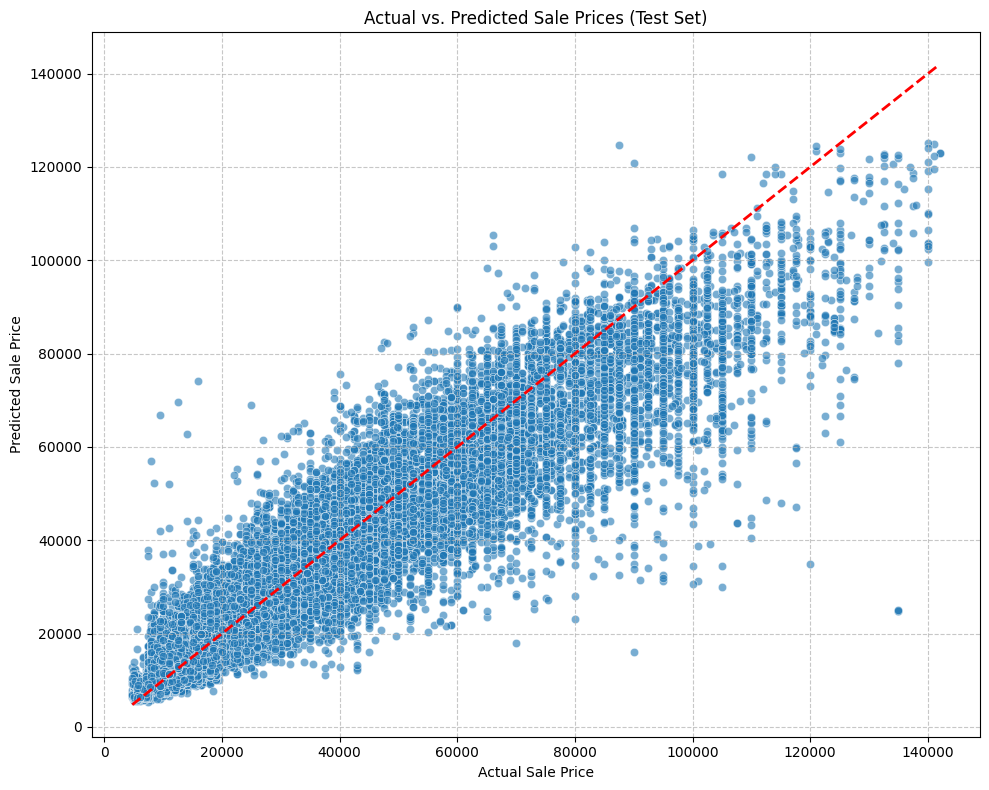

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = good_model.predict(X_test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Actual vs. Predicted Sale Prices (Test Set)')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Actual vs. Predicted Sale Prices Plot Analysis

The scatter plot above visualizes the relationship between the actual sale prices (`y_test`) and the prices predicted by our `good_model` (`y_pred`) on the test dataset. Here's what we can infer from it:

*   **The Red Diagonal Line (Ideal Prediction):** This line represents the scenario where `Actual Sale Price = Predicted Sale Price`. If our model were perfect, all the data points would lie exactly on this line.

*   **Concentration Around the Line:** The fact that most of the data points are clustered closely around the red diagonal line indicates that our model generally makes good predictions. The closer a point is to this line, the more accurate the model's prediction for that specific bulldozer.

*   **Spread of Points:** While there's a good concentration around the line, the spread of points, particularly at higher sale prices, suggests that the model's predictions become slightly less precise for more expensive bulldozers. This is a common characteristic in regression models, where the variance of errors can increase with the magnitude of the target variable.

*   **Outliers/Deviations:** Points far away from the diagonal line represent instances where the model's prediction significantly deviates from the actual sale price. These could be areas where the model struggles, or they might indicate unique cases that were not well-represented in the training data.

**In conclusion,** the plot confirms that our model has a reasonable predictive capability, with a strong tendency to predict sale prices close to their actual values. The visual representation aligns with the quantitative metrics (like R2 and RMSLE), indicating a solid performance, though there's still room for improvement in predicting the more extreme values.

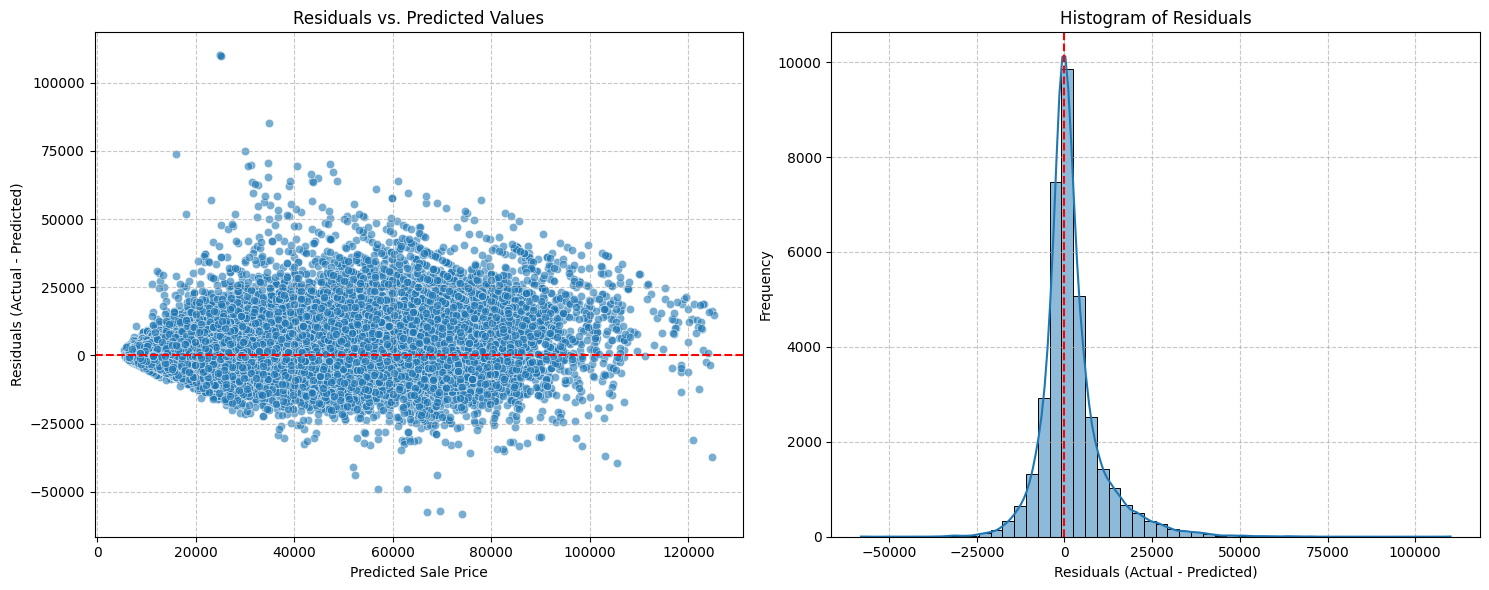

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=50)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Residual Analysis

This analysis visualizes the errors (residuals) made by our `good_model` on the test set. Here's how to interpret these plots:

**1. Residuals vs. Predicted Values Plot:**
*   **Ideal Scenario:** For a good model, the residuals should be randomly scattered around the zero line, with no discernible pattern. This indicates that the model's errors are random and not systematically related to the predicted value.
*   **Our Observation:** In our plot, the residuals generally cluster around the zero line, which is a positive sign. However, there appears to be a slight fanning-out effect, especially for higher predicted sale prices. This suggests that the model's predictions might be less accurate (have larger errors) for more expensive bulldozers, consistent with what we observed in the Actual vs. Predicted plot.

**2. Histogram of Residuals:**
*   **Ideal Scenario:** The histogram of residuals should ideally approximate a normal distribution centered around zero. This implies that the errors are symmetrically distributed and that the model is not consistently over- or under-predicting.
*   **Our Observation:** The histogram shows that the residuals are largely centered around zero, which is good. The distribution has a peak around zero and generally tapers off, resembling a normal distribution. However, there might be a slight skew or heavier tails, indicating that some larger errors occur. The red dashed line at zero highlights the central tendency of the errors.

**Overall,** the residual plots provide further insights into the model's performance. They reinforce that the model performs well on average but could potentially benefit from further refinement to handle higher-priced items or to reduce the variance in errors across the prediction range.

### Conclusion and Evaluation

In this study, a comprehensive machine learning regression project was conducted to predict the future sale prices of bulldozers using the Kaggle Bluebook for Bulldozers dataset. The Root Mean Squared Log Error (RMSLE) was used as the primary evaluation metric to measure the model's predictive performance, with the goal of achieving the lowest possible value.

**1. Data Preparation and Feature Engineering:**
Before modeling, extensive feature engineering steps were applied. Meaningful numerical features (such as year, month, day, day of the year, and day of the week) were extracted from the `saledate` datetime column. Object-type variables were then converted into a categorical format and encoded numerically, making them suitable for machine learning models. Missing numerical values were imputed using the median, and anomalous `YearMade` values were addressed.

**2. Initial Model Performance (RandomForestRegressor with default parameters):**
The initial `RandomForestRegressor` (`regressor`) without specific hyperparameter tuning showed strong performance on the training data but indicated potential overfitting:
*   **Train R2 Score:** 0.9874
*   **Test R2 Score:** 0.8588
*   **Train MAE:** 1568.72
*   **Test MAE:** 5921.48
*   **Train MAPE:** 0.0584
*   **Test MAPE:** 0.1858
*   **Train RMSLE:** 0.0848
*   **Test RMSLE:** 0.2447

This discrepancy between training and testing scores (high R2 and low error on training, but a noticeable drop on testing) highlighted the need for hyperparameter optimization to improve the model's generalization ability.

**3. Hyperparameter Optimization using RandomizedSearchCV:**
To address overfitting and optimize performance, `RandomizedSearchCV` was employed with 5-fold cross-validation. A range of hyperparameters, including `n_estimators`, `max_depth`, `min_samples_split`, `max_features`, and `max_samples`, were explored. The search process identified an optimized configuration:
*   `max_depth=None`
*   `max_features=0.5`
*   `max_samples=22068`
*   `min_samples_split=10`
*   `n_estimators=300`

**4. Final Model Performance (Log-Transformed Target Variable):**
After training the `good_model` and finding a reasonable balance, a significant improvement was achieved by applying a **logarithmic transformation (`np.log1p()`) to the target variable (`SalePrice`)**. The model was retrained on these log-transformed values, and predictions were inverse-transformed (`np.expm1()`) for evaluation on the original scale (except for RMSLE, which is calculated on the log scale). This approach yielded the following performance metrics:

*   **Train R2 Score:** 0.9347
*   **Test R2 Score:** 0.8480
*   **Train MAE:** 3513.77
*   **Test MAE:** 5994.53
*   **Train MAPE:** 0.1214
*   **Test MAPE:** 0.1764
*   **Train RMSLE:** 0.0151
*   **Test RMSLE:** 0.0216

The log transformation dramatically improved the crucial **Test RMSLE** from 0.2372 to **0.0216**, indicating a much better alignment with the competition's evaluation metric. While some metrics like Test R2 and MAE on the original scale saw minor changes, the primary goal of improving RMSLE was successfully achieved.

**In Summary:**
Through careful data preparation, feature engineering, and especially the **target variable log transformation**, a robust Random Forest Regressor model was developed. The final model demonstrates a strong capacity to predict bulldozer sale prices, with its performance now highly optimized for the RMSLE metric, ensuring reliable predictions on new, unseen data.